Colab de referência: https://colab.research.google.com/drive/1s0wK-XDQOdUubutjqhJVQL-6q6jKAfy9

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder

data = fetch_california_housing(as_frame=True)

df = data.frame

# adicionar a característica 'ocean_proximity' no DataFrame com valor aleatório (um dos três) passados na lista
df['ocean_proximity'] = np.random.choice(['<1H OCEAN', 'INLAND', 'NEAR OCEAN'], size=len(df))

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,<1H OCEAN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,INLAND
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,INLAND
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,INLAND
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,<1H OCEAN


##### Min-Max Scalling

As colunas *MedInc* (representa o nível de renda da região onde o imóvel está localizado) e *AveOccup* (representa a ocupação média por imóvel) serão usadas para testar as técnicas de normalização.

O **min-max scalling** escala os valores de cada característica para o intervalo [0,1].

<Axes: xlabel='MedInc', ylabel='AveOccup'>

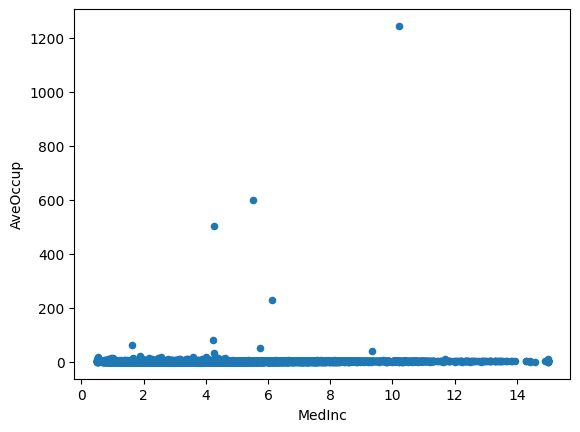

In [2]:
# Distribuição dos dados ANTES da normalização
# Note que MedInc varia de 0-14 e AveOcupp de 0-1200.
df.plot.scatter(x='MedInc', y='AveOccup')

##### Normalização

In [3]:
scaler = MinMaxScaler()

df[['MedInc', 'AveOccup']] = scaler.fit_transform(df[['MedInc', 'AveOccup']])

df[['MedInc', 'AveOccup']].head()

,MedInc,AveOccup
0,0.539668,0.001499
1,0.538027,0.001141
2,0.466028,0.001698
3,0.354699,0.001493
4,0.230776,0.001198


<Axes: xlabel='MedInc', ylabel='AveOccup'>

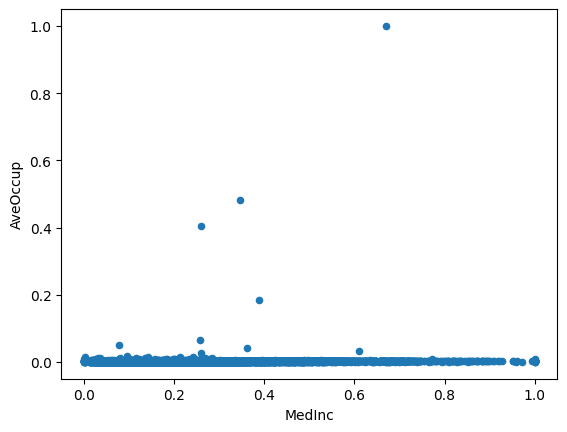

In [4]:
# Plotando os dados APÓS a redefinição da escala. Ambas características estão no intervalo [0,1].
df.plot.scatter(x='MedInc', y='AveOccup')

##### Z-score Standardization

Este método de normalização centraliza os dados (**média=0**) e escala para ter variância unitária (**desvio padrão=1**)

In [5]:
scaler = StandardScaler()

df[['MedInc', 'AveOccup']] = scaler.fit_transform(df[['MedInc', 'AveOccup']])

df[['MedInc', 'AveOccup']].head()

,MedInc,AveOccup
0,2.344766,-0.049597
1,2.332238,-0.092512
2,1.782699,-0.025843
3,0.932968,-0.050329
4,-0.012881,-0.085616


In [6]:
print("Média dos valores após a normalização")
print(df[['MedInc', 'AveOccup']].mean())

Média dos valores após a normalização
MedInc      1.927829e-16
AveOccup   -4.027786e-17
dtype: float64


In [7]:
print("Desvio padrão dos valores após a normalização")
print(df[['MedInc', 'AveOccup']].std())

Desvio padrão dos valores após a normalização
MedInc      1.000024
AveOccup    1.000024
dtype: float64


<Axes: xlabel='MedInc', ylabel='AveOccup'>

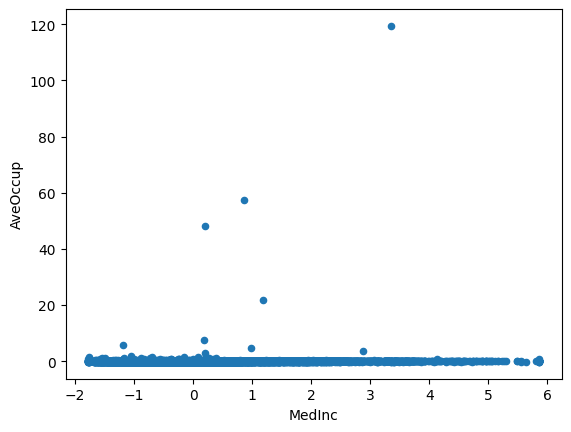

In [8]:
df.plot.scatter(x='MedInc', y='AveOccup')

#### Codificação de variáveis categóricas

* Este é o processo de conversão de variáveis não-numéricas em numéricas;

* **Métodos**:
    * *One-hot encoding*: cria colunas binárias para cada categoria;
    * *Label encondig*: atribui um número inteiro para cada categoria;

##### Quando usar saída esparsa (**sparse_output=True**)

* Se a sua variável categórica tem muitas categorias e, portanto, o one‑hot vai gerar muitas colunas.
* Em muitos casos essas colunas terão muitos zeros (pois cada instância ativa apenas uma categoria, ou poucas). Nesse cenário, o uso de matriz esparsa faz sentido porque economiza memória e possivelmente melhora desempenho em transformações ou em pipelines que suportam matrizes esparsas.
* Se o algoritmo ou pipeline aceita bem matrizes esparsas.

##### Quando usar saída densa (**sparse_output=False**)

* Se você precisa de um array denso para alguma etapa subsequente — por exemplo, para converter em pandas DataFrame, ou para alguma visualização ou manipulação que exige matriz normal.
* Se o número de colunas após codificação não for muito grande, então o custo de armazenar como denso é aceitável.
* Se o método subsequente não aceita matrizes esparsas ou isso causa complicações.

##### One-Hot Encoding

In [9]:
# O parâmetro sparse_output=False indica que o resultado será uma matriz densa.
# Todos os valores explicitamente armazenados
encoder = OneHotEncoder()

# transformar as características da proximidade do oceano em números binários
encoded_features = encoder.fit_transform(df[['ocean_proximity']])

# criar novo dataframe
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['ocean_proximity']))

# criar dataframe com as colunas binárias e retirar a variável 'ocean_proximity' categória (não numérica)
df_one_hot = df.join(encoded_df).drop(columns=['ocean_proximity'])

In [10]:
# verificando as novas colunas com codificação One Hot Encoding
encoded_df.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR OCEAN
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


In [11]:
# Verificando o dataframe por completo. Veja que agora a coluna 'ocean_proximity' foi transformada em três.
df_one_hot.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR OCEAN
0,2.344766,41.0,6.984127,1.023810,322.0,-0.049597,37.88,-122.23,4.526,1.0,0.0,0.0
1,2.332238,21.0,6.238137,0.971880,2401.0,-0.092512,37.86,-122.22,3.585,0.0,1.0,0.0
2,1.782699,52.0,8.288136,1.073446,496.0,-0.025843,37.85,-122.24,3.521,0.0,1.0,0.0
3,0.932968,52.0,5.817352,1.073059,558.0,-0.050329,37.85,-122.25,3.413,0.0,1.0,0.0
4,-0.012881,52.0,6.281853,1.081081,565.0,-0.085616,37.85,-122.25,3.422,1.0,0.0,0.0


##### Label-Encoding

De forma análoga, o LabelEcoder atribui um **único número** para cada categoria.

In [12]:
encoder = LabelEncoder()

df['ocean_proximity'] = encoder.fit_transform(df['ocean_proximity'])

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity
0,2.344766,41.0,6.984127,1.023810,322.0,-0.049597,37.88,-122.23,4.526,0
1,2.332238,21.0,6.238137,0.971880,2401.0,-0.092512,37.86,-122.22,3.585,1
2,1.782699,52.0,8.288136,1.073446,496.0,-0.025843,37.85,-122.24,3.521,1
3,0.932968,52.0,5.817352,1.073059,558.0,-0.050329,37.85,-122.25,3.413,1
4,-0.012881,52.0,6.281853,1.081081,565.0,-0.085616,37.85,-122.25,3.422,0


In [13]:
# verificando as classes que foram atribuídas
encoder.classes_

array(['<1H OCEAN', 'INLAND', 'NEAR OCEAN'], dtype=object)

##### Exercício 1: Normalize a coluna 'AveRooms' utilizando o Min-Max Scaling.
* importar a função de scaling;
* reassinalar o DataFrame, fazendo a transformação.

In [14]:
scaler = MinMaxScaler()
df['AveRooms'] = scaler.fit_transform(df[['AveRooms']])
df[['AveRooms']].head()

,AveRooms
0,0.043512
1,0.038224
2,0.052756
3,0.035241
4,0.038534
